# Demo of the latent sampling in StyleGAN2

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

import pickle

import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
STYLEGAN2_DIR = PROJECT_DIR / 'stylegan2'
if str(STYLEGAN2_DIR) not in sys.path:
    sys.path.insert(0, str(STYLEGAN2_DIR))

from stylegan2 import *
from stylegan2.torch_utils.misc import get_device

In [9]:
# SEED = 6
SEED = 7
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

OUT_DIR = Path('out')

device = get_device()
print(device)

mps


In [10]:
def preprocess_prediction(pred: torch.Tensor) -> torch.Tensor:
    img = (pred + 1.0) / 2.0
    img = torch.clip(img, 0.0, 1.0)
    return img

def prediction_to_img(pred: torch.Tensor) -> np.ndarray:
    img = preprocess_prediction(pred)
    img = img[0].permute(1, 2, 0)
    np_img = img.cpu().numpy()

    return np_img

In [11]:
with open('models/ffhq.pkl', 'rb') as f:
    G = pickle.load(f)['G_ema'].to(device)


/var/folders/pc/hcpfk3hd2_qbyhc3695l5gfw0000gn/T/ipykernel_51663/3389835213.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  G = pickle.load(f)['G_ema'].to(device)


## Sampling in the $\mathcal{Z}$ latent space

In [12]:
z = torch.randn([1, G.z_dim]).to(device)
w = G.mapping(z, None)
pred = G.synthesis(w)

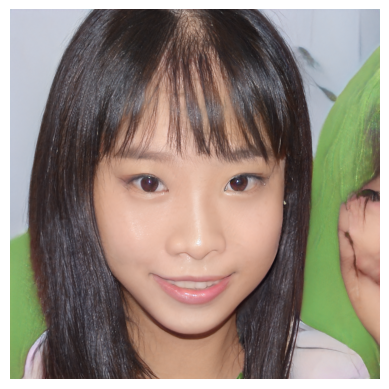

In [13]:
img = prediction_to_img(pred)

_ = plt.imshow(img)
_ = plt.axis('off')
_ = plt.show()

## Interpolation in the $\mathcal{Z}$ and $\mathcal{W}$ latent space

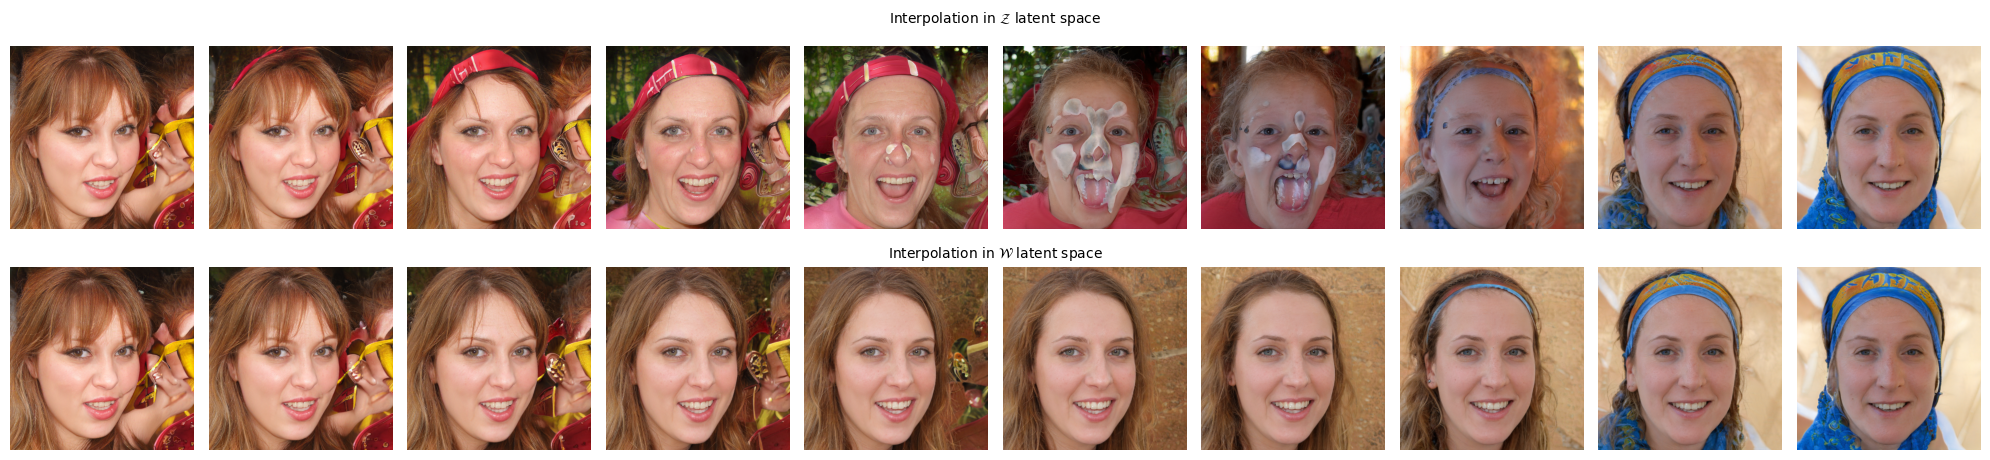

In [14]:
N_INTERPOLATION = 10

z1 = torch.randn([1, G.z_dim]).to(device)
z2 = torch.randn([1, G.z_dim]).to(device)

w1 = G.mapping(z1, None)
w2 = G.mapping(z2, None)

fig = plt.figure(figsize=(2*N_INTERPOLATION, 5))
for i in range(N_INTERPOLATION):
    t = i / (N_INTERPOLATION-1)

    z = (1 - t) * z1 + t * z2
    w = (1 - t) * w1 + t * w2

    with torch.no_grad():
        pred = G.synthesis(G.mapping(z, None))
    ax = plt.subplot(2, N_INTERPOLATION, i+1)
    _ = ax.imshow(prediction_to_img(pred))
    ax.set_axis_off()
    
    with torch.no_grad():
        pred = G.synthesis(w)
    ax = plt.subplot(2, N_INTERPOLATION, N_INTERPOLATION+i+1)
    _ = ax.imshow(prediction_to_img(pred))
    ax.set_axis_off()

_ = fig.text(0.5, 0.95, r'Interpolation in $\mathcal{Z}$ latent space', ha="center")
_ = fig.text(0.5, 0.48, r'Interpolation in $\mathcal{W}$ latent space', ha="center")
plt.tight_layout()
_ = plt.show()